# Anomaly Detection

In [7]:
# pylint: disable=missing-module-docstring
import numpy as np
from numpy.typing import NDArray
from typing import Tuple
import matplotlib.pyplot as plt

def load_data() -> Tuple[NDArray, NDArray, NDArray]:
    # pylint: disable=missing-function-docstring
    x = np.load("data/anomaly_detection/X_part1.npy")
    x_val = np.load("data/anomaly_detection/X_val_part1.npy")
    y_val = np.load("data/anomaly_detection/y_val_part1.npy")
    return x, x_val, y_val

def load_data_multi() -> Tuple[NDArray, NDArray, NDArray]:
    # pylint: disable=missing-function-docstring
    x = np.load("data/anomaly_detection/X_part2.npy")
    x_val = np.load("data/anomaly_detection/X_val_part2.npy")
    y_val = np.load("data/anomaly_detection/y_val_part2.npy")
    return x, x_val, y_val

def visualize_fit(X, mu, var):
    """
    This visualization shows you the 
    probability density function of the Gaussian distribution. Each example
    has a location (x1, x2) that depends on its feature values.
    """
    
    X1, X2 = np.meshgrid(np.arange(0, 35.5, 0.5), np.arange(0, 35.5, 0.5))
    Z = compute_gaussian(np.stack([X1.ravel(), X2.ravel()], axis=1), mu, var)
    Z = Z.reshape(X1.shape)

    plt.plot(X[:, 0], X[:, 1], 'bx')

    if np.sum(np.isinf(Z)) == 0:
        plt.contour(X1, X2, Z, levels=10**(np.arange(-20., 1, 3)), linewidths=1)
        
    # Set the title
    plt.title("The Gaussian contours of the distribution fit to the dataset")
    # Set the y-axis label
    plt.ylabel('Throughput (mb/s)')
    # Set the x-axis label
    plt.xlabel('Latency (ms)')

The shape of x_train is: (307, 2)
The shape of x_val is: (307, 2)
The shape of y_val is:  (307,)


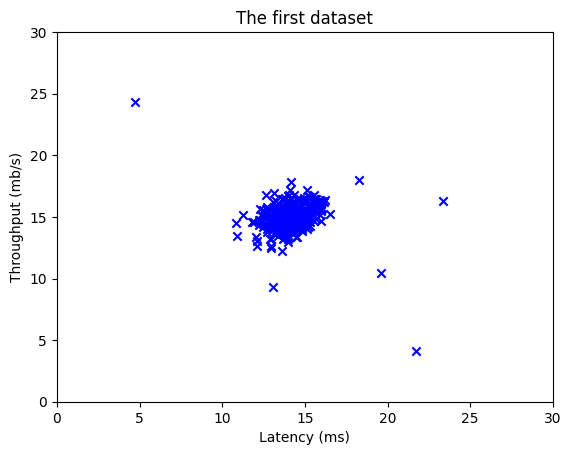

In [8]:
x_train, x_val, y_val = load_data()
print ('The shape of x_train is:', x_train.shape)
print ('The shape of x_val is:', x_val.shape)
print ('The shape of y_val is: ', y_val.shape)

plt.scatter(x_train[:, 0], x_train[:, 1], marker='x', c='b') 

# Set the title
plt.title("The first dataset")
# Set the y-axis label
plt.ylabel('Throughput (mb/s)')
# Set the x-axis label
plt.xlabel('Latency (ms)')
# Set axis range
plt.axis([0, 30, 0, 30])
plt.show()

In [9]:
def estimate_gaussian(x: NDArray) -> Tuple[NDArray, NDArray]:
    # pylint: disable=missing-function-docstring
    m = x.shape[0]

    mu = (1 / m) * np.sum(x, axis=0)
    sigma = (1 / m) * np.sum((x - mu)**2, axis=0)

    return mu, sigma

mu, sigma = estimate_gaussian(x_train)              
print("Mean of each feature:", mu)
print("Variance of each feature:", sigma)

Mean of each feature: [14.11222578 14.99771051]
Variance of each feature: [1.83263141 1.70974533]


* Recall that the Gaussian distribution is given by

   $$ p(x ; \mu,\sigma ^2) = \frac{1}{\sqrt{2 \pi \sigma ^2}}\exp^{ - \frac{(x - \mu)^2}{2 \sigma ^2} }$$
   $$\mu_i = \frac{1}{m} \sum_{j=1}^m x_i^{(j)}$$
   $$\sigma_i^2 = \frac{1}{m} \sum_{j=1}^m (x_i^{(j)} - \mu_i)^2$$

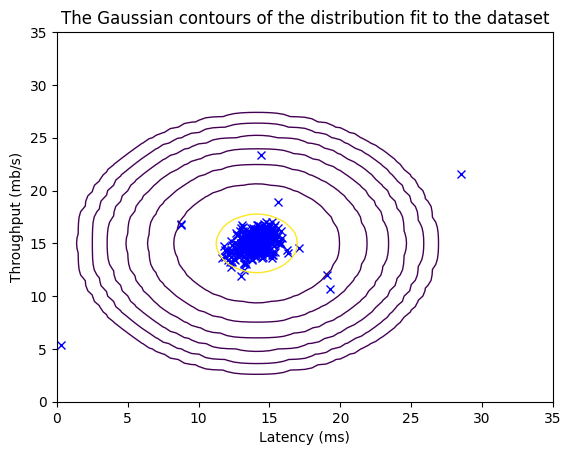

In [10]:
def compute_gaussian(x: NDArray, mu: NDArray, sigma: NDArray) -> NDArray:
    # pylint: disable=missing-function-docstring
    p = (1 / np.sqrt(2 * np.pi * sigma)) * np.exp(- (x - mu)**2  / (2 * sigma))
    if p.ndim > 1:
        p = np.prod(p, axis=1)
    return p

# def multivariate_gaussian(X, mu, var):
#     """
#     Computes the probability 
#     density function of the examples X under the multivariate gaussian 
#     distribution with parameters mu and var. If var is a matrix, it is
#     treated as the covariance matrix. If var is a vector, it is treated
#     as the var values of the variances in each dimension (a diagonal
#     covariance matrix
#     """
    
#     k = len(mu)
    
#     if var.ndim == 1:
#         var = np.diag(var)
        
#     X = X - mu
#     p = (2* np.pi)**(-k/2) * np.linalg.det(var)**(-0.5) * \
#         np.exp(-0.5 * np.sum(np.matmul(X, np.linalg.pinv(var)) * X, axis=1))
    
#     return p

p = compute_gaussian(x_val, mu, sigma)

visualize_fit(x_val, mu, sigma)

In [12]:
def select_threshold(y_val: NDArray, p_val: NDArray) -> Tuple[float, float]: 
    best_epsilon = 0
    best_f1 = 0

    p_max = np.max(p_val)
    p_min = np.min(p_val)
    step_size = (p_max - p_min) / 1000
    for epsilon in np.arange(p_min, p_max, step_size):
        predictions = (p_val < epsilon)
        tp = np.sum((predictions == 1) & (y_val == 1))
        fp = np.sum((predictions == 1) & (y_val == 0))
        fn = np.sum((predictions == 0) & (y_val == 1))

        precision = tp / (tp + fp) if (tp + fp) > 0 else 0
        recall = tp / (tp + fn) if (tp + fn) > 0 else 0

        f1_score = (2 * precision * recall) / (precision + recall) if (precision + recall) > 0 else 0

        if f1_score > best_f1:
            best_f1 = f1_score
            best_epsilon = epsilon

    return best_epsilon, best_f1

p = compute_gaussian(x_val, mu, sigma)
epsilon, f1 = select_threshold(y_val, p)
print(f'Best epsilon {epsilon} and F1 {f1}')

Best epsilon 8.990852779269493e-05 and F1 0.8750000000000001


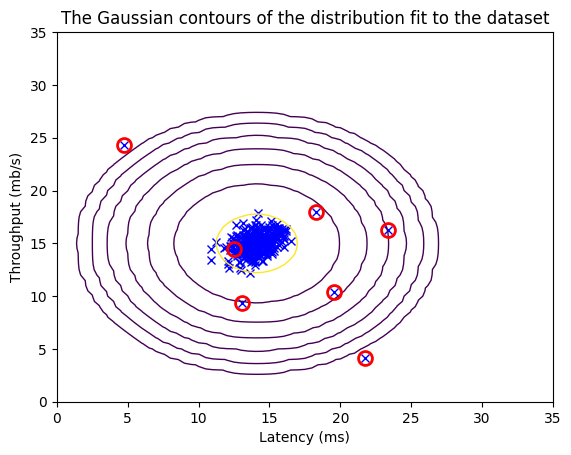

In [14]:
outliers = p < epsilon
# Visualize the fit
visualize_fit(x_train, mu, sigma)

# Draw a red circle around those outliers
plt.plot(x_train[outliers, 0], x_train[outliers, 1], 'ro',
         markersize= 10,markerfacecolor='none', markeredgewidth=2)

## Hight Dimension

In [15]:
x_high, x_val_high, y_val_high = load_data_multi()
print ('The shape of x_high is:', x_high.shape)
print ('The shape of x_val_high is:', x_val_high.shape)
print ('The shape of y_val_high is: ', y_val_high.shape)

The shape of x_high is: (1000, 11)
The shape of x_val_high is: (100, 11)
The shape of y_val_high is:  (100,)


In [16]:
mu, var = estimate_gaussian(x_high)
p_high = compute_gaussian(x_val_high, mu, var)
epsilon_high, f1_high = select_threshold(y_val_high, p_high)
print(f'Best epsilon {epsilon_high} and F1 {f1_high}')
print('# Anomalies found: %d'% sum(p_high < epsilon_high))

Best epsilon 1.377228890761357e-18 and F1 0.6153846153846154
# Anomalies found: 16
